Author: Kostya Malanchev, Neven Caplar and the LINCC Frameworks team

Last updated: May 04, 2026

# Problem 2

## Compare with spectroscopic DESI redshifts

Let's compare photometric redshifts with spectroscopic ones. Crossmatch with DESI spectroscopical redshift catalog that covers the southern sky (available at https://data.lsdb.io/#DESI/DESI_DR1_(z-catalog)) and plot the results of any photo-z method compared with spectroscopical redshifts.

# Solution 2

In [1]:
import lsdb
import matplotlib.pyplot as plt

In [2]:
# we open catalog from the main notebook
dp1_pz_catalog = lsdb.open_catalog('/rubin/lsdb_data/object_photoz/')

In [12]:
# we open the remote catalog and do a simple crossmatch
desi_specz_catalog = lsdb.open_catalog("s3://stpubdata/desi/public/hats/desi_dr1_zcat")
xmatch = desi_specz_catalog.crossmatch(dp1_pz_catalog, radius_arcsec=0.25, suffix_method='overlapping_columns').compute()
xmatch

Computing Catalog:   0%|          | 0/15 [00:00<?, ?it/s]

TARGETID SURVEY PROGRAM  HEALPIX  SPGRPVAL  \
_healpix_29                                                                
9196001173684025     39627930157977455   main    dark      130       130   
9196012838269317     39627930157977193   main    dark      130       130   
...                                ...    ...     ...      ...       ...   
1258720322824063601  39627948168315100   main    dark    17887     17887   
1258720359354871478  39627948168315027   main    dark    17887     17887   

                            Z      ZERR  ZWARN          CHI2  \
_healpix_29                                                    
9196001173684025     0.850773  0.000021      0   7997.277847   
9196012838269317     0.850223  0.000108      0   7622.568687   
...                       ...       ...    ...           ...   
1258720322824063601  0.798532   0.00001      0   7859.767879   
1258720359354871478  0.731372  0.000008      0  10567.344088   

                                                                 COEFF  ...  \
_healpix_29                                                             ...   
9196001173684025     [32.70940105 -3.00733231 -8.46577691  1.761497...  ...   
9196012838269317     [78.98068013 88.18227092 -3.70094894  3.357942...  ...   
...                                                                ...  ...   
1258720322824063601  [ 74.5743256  -48.40134383  -1.54873073 -23.13...  ...   
1258720359354871478  [ 122.97607873  199.50647147 -114.70399837  10...  ...   

                                          cmnn_ens_norm  \
_healpix_29                                               
9196001173684025       [{loc: 0.6346, scale: 0.981378}]   
9196012838269317         [{loc: 0.735, scale: 1.38876}]   
...                                                 ...   
1258720322824063601  [{loc: 0.926158, scale: 0.435926}]   
1258720359354871478  [{loc: 0.680861, scale: 0.432523}]   

                                                        dnf_ens_interp  \
_healpix_29                                                              
9196001173684025     [{xvals: 0.0, yvals: 1.055876e-269}; …] (301 r...   
9196012838269317     [{xvals: 0.0, yvals: 5.844941e-16}; …] (301 rows)   
...                                                                ...   
1258720322824063601  [{xvals: 0.0, yvals: 2.956504e-27}; …] (301 rows)   
1258720359354871478      [{xvals: 0.0, yvals: 0.000189}; …] (301 rows)   

                                                fzboost_ens_interp  \
_healpix_29                                                          
9196001173684025          [{xvals: 0.0, yvals: 0.0}; …] (301 rows)   
9196012838269317          [{xvals: 0.0, yvals: 0.0}; …] (301 rows)   
...                                                            ...   
1258720322824063601       [{xvals: 0.0, yvals: 0.0}; …] (301 rows)   
1258720359354871478  [{xvals: 0.0, yvals: 0.761466}; …] (301 rows)   

                                                        knn_ens_mixmod  \
_healpix_29                                                              
9196001173684025     [{means: 2.003705, stds: 0.024444, weights: 0....   
9196012838269317     [{means: 2.003705, stds: 0.024444, weights: 0....   
...                                                                ...   
1258720322824063601  [{means: 2.003705, stds: 0.024444, weights: 0....   
1258720359354871478  [{means: 2.003705, stds: 0.024444, weights: 0....   

                                           lephare_ens_interp  \
_healpix_29                                                     
9196001173684025     [{xvals: 0.0, yvals: 0.0}; …] (401 rows)   
9196012838269317     [{xvals: 0.0, yvals: 0.0}; …] (401 rows)   
...                                                       ...   
1258720322824063601  [{xvals: 0.0, yvals: 0.0}; …] (401 rows)   
1258720359354871478  [{xvals: 0.0, yvals: 0.0}; …] (401 rows)   

                                                        tpz_ens_interp  \
_healpix_29          

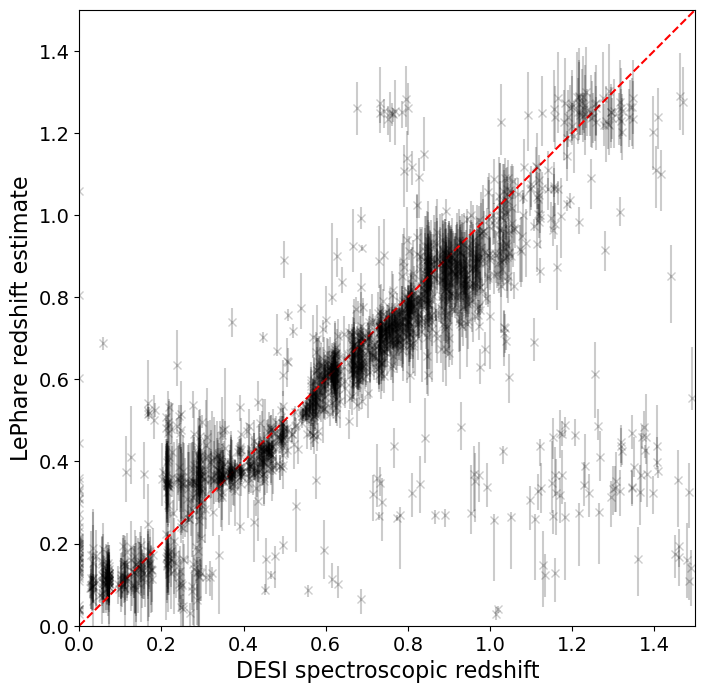

In [16]:
plt.figure(figsize=(8, 8))

# Filter out object for which lephare has wide spread 
low_error = xmatch.query("lephare_z_err68_high - lephare_z_err68_low < 0.2")

# Plot with errorbars
plt.errorbar(
    x=low_error["Z"],
    y=low_error["lephare_z_median"],
    yerr=[
        low_error["lephare_z_err68_high"] - low_error["lephare_z_median"],
        low_error["lephare_z_median"] - low_error["lephare_z_err68_low"],
    ],
    fmt="x",
    color="black",
    alpha=0.2,
)

# Set equal aspect ratio
plt.gca().set_aspect("equal", adjustable="box")

# Plot reference y=x line
plt.plot([0, 1.5], [0, 1.5], color="red", ls="--")

# Set axis limits
plt.xlim([0, 1.5])
plt.ylim([0, 1.5])

# Set axis labels with larger font size and descriptions
plt.xlabel("DESI spectroscopic redshift", fontsize=16)
plt.ylabel("LePhare redshift estimate", fontsize=16)

# Make tick labels larger
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()